In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
from scipy import stats

nltk.download('vader_lexicon', quiet=True)
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['font.family'] = 'serif'
print("Environment Ready!")

Environment Ready!


Date loading

In [57]:

import sys
import os

#  Tell the notebook where to find your 'src' folder
sys.path.append(os.path.abspath('../'))
from src.data_loader import load_data
# Define the path to the sentiment dataset  file

df_sentiment = load_data("../data/raw/raw_analyst_ratings.csv")
aapl_stock = load_data("../data/processed/aapl_processed.csv")
amzn_stock = load_data("../data/processed/amzn_processed.csv")
goog_stock = load_data("../data/processed/goog_processed.csv")
meta_stock = load_data("../data/processed/meta_processed.csv")
nvda_stock = load_data("../data/processed/nvda_processed.csv")





In [58]:
selected_stocks = ['AAPL', 'META', 'NVDA', 'AMZN', 'GOOG']

filtered_counts = (
    df_sentiment[df_sentiment['stock'].isin(selected_stocks)]
    ['stock'].value_counts().reset_index())
filtered_counts.columns = ['stock', 'article_count']
filtered_counts



,stock,article_count
0,NVDA,3146
1,GOOG,1199
2,AAPL,441
3,AMZN,278


From the above we can see that the headlines that are related to meta are not visible this is because meta was not using new ticker 'META' in a given dataset timeline. It has been using 'FB' therefore we can use old ticker to access the sentiments.

In [48]:
selected_stocks = ['AAPL', 'FB', 'NVDA', 'AMZN', 'GOOG']

filtered_counts = (
    df_sentiment[df_sentiment['stock'].isin(selected_stocks)]
    ['stock'].value_counts().reset_index())
filtered_counts.columns = ['stock', 'article_count']
filtered_counts

,stock,article_count
0,NVDA,3146
1,GOOG,1199
2,AAPL,441
3,FB,380
4,AMZN,278


Date Alignment

In [83]:
# 1. Import your function from the module
from src.data_alignment import align_company_data, apply_vader_sentiment, aggregate_daily_data

# 2. Run the function for each company's specific datasets 

filtered_apple = align_company_data('AAPL', aapl_stock, df_sentiment)
filtered_nvda  = align_company_data('NVDA', nvda_stock, df_sentiment)
filtered_meta  = align_company_data('FB', meta_stock, df_sentiment)
filtered_googl = align_company_data('GOOG', goog_stock, df_sentiment)
filtered_amzn  = align_company_data('AMZN', amzn_stock, df_sentiment)

To accurately measure the impact of news sentiment on stock prices, we implemented a data alignment pipeline that standardizes continuous news  against  stock market calendars. The process begins by isolating the data by specific ticker symbols to prevent cross-contamination, followed by sorting both datasets chronologically. Finally, we use pandas' forward-looking merge_asof function to merge the data; this takes weekend and holiday edge cases by automatically snapping non-trading day news to the next open market.

Sentiment Analysis


In [77]:
# Apply the sentiment analysis to each aligned company dataset
scored_apple = apply_vader_sentiment(filtered_apple)
scored_nvda  = apply_vader_sentiment(filtered_nvda)
scored_meta  = apply_vader_sentiment(filtered_meta)
scored_googl = apply_vader_sentiment(filtered_googl)
scored_amzn  = apply_vader_sentiment(filtered_amzn)

# Check the results for Apple to see the new columns!
print(scored_apple[[ 'headline', 'vader_compound']].head())

                                            headline  vader_compound
0      101 Stocks Moving In Monday's Mid-Day Session          0.0000
1     Investor Movement Index Summary: February 2020          0.0000
2  Crude Awakening: Energy Sector Takes A 20% Spi...         -0.9062
3                  123 Biggest Movers From Yesterday          0.0000
4  UBS Maintains Buy on Apple, Lowers Price Targe...         -0.1280


VADER is a rule-based sentiment analysis tool built specifically for short, punchy text like news headlines. It uses a massive, pre-scored dictionary to instantly spot positive and negative financial words. It is smart enough to adjust those scores based on context clues like ALL CAPS, exclamation points!, and modifying words. It aggregates everything into a single "Compound Score" ranging from -1.0 (extreme negative) to +1.0 (extreme positive). We chose it because it requires zero training data and perfectly captures the emotional intensity that drives stock market reactions.

Calculate Daily Stock Returns (Already done in task 2)


In [80]:
# 1. Convert decimals to percentages (e.g., -0.014 -> -1.41)
scored_apple['Daily_Return'] = scored_apple['Daily_Return'] * 100
scored_nvda['Daily_Return'] = scored_nvda['Daily_Return'] * 100
scored_amzn['Daily_Return'] = scored_amzn['Daily_Return'] * 100
scored_googl['Daily_Return'] = scored_googl['Daily_Return'] * 100
scored_meta['Daily_Return'] = scored_meta['Daily_Return'] * 100

# 2. Check a larger sample to see the price actually change
print("=== Apple: Verifying Price Movement ===")
print(scored_apple[['Date', 'Close', 'Daily_Return', 'vader_compound']].head(15))

=== Apple: Verifying Price Movement ===
                        Date      Close  Daily_Return  vader_compound
0  2020-03-09 00:00:00+00:00  64.373756     -7.909217          0.0000
1  2020-03-09 00:00:00+00:00  64.373756     -7.909217          0.0000
2  2020-03-09 00:00:00+00:00  64.373756     -7.909217         -0.9062
3  2020-03-10 00:00:00+00:00  69.010056      7.202157          0.0000
4  2020-03-10 00:00:00+00:00  69.010056      7.202157         -0.1280
5  2020-03-10 00:00:00+00:00  69.010056      7.202157          0.2960
6  2020-03-10 00:00:00+00:00  69.010056      7.202157         -0.8271
7  2020-03-10 00:00:00+00:00  69.010056      7.202157         -0.4404
8  2020-03-10 00:00:00+00:00  69.010056      7.202157          0.0772
9  2020-03-10 00:00:00+00:00  69.010056      7.202157          0.0000
10 2020-03-10 00:00:00+00:00  69.010056      7.202157          0.2960
11 2020-03-11 00:00:00+00:00  66.613319     -3.473025          0.0000
12 2020-03-11 00:00:00+00:00  66.613319     -3.473

Aggregate and Correlate


In [84]:
final_apple = aggregate_daily_data(scored_apple)
final_nvda  = aggregate_daily_data(scored_nvda)
final_meta  = aggregate_daily_data(scored_meta)
final_googl = aggregate_daily_data(scored_googl)
final_amzn  = aggregate_daily_data(scored_amzn)

correlation analysis

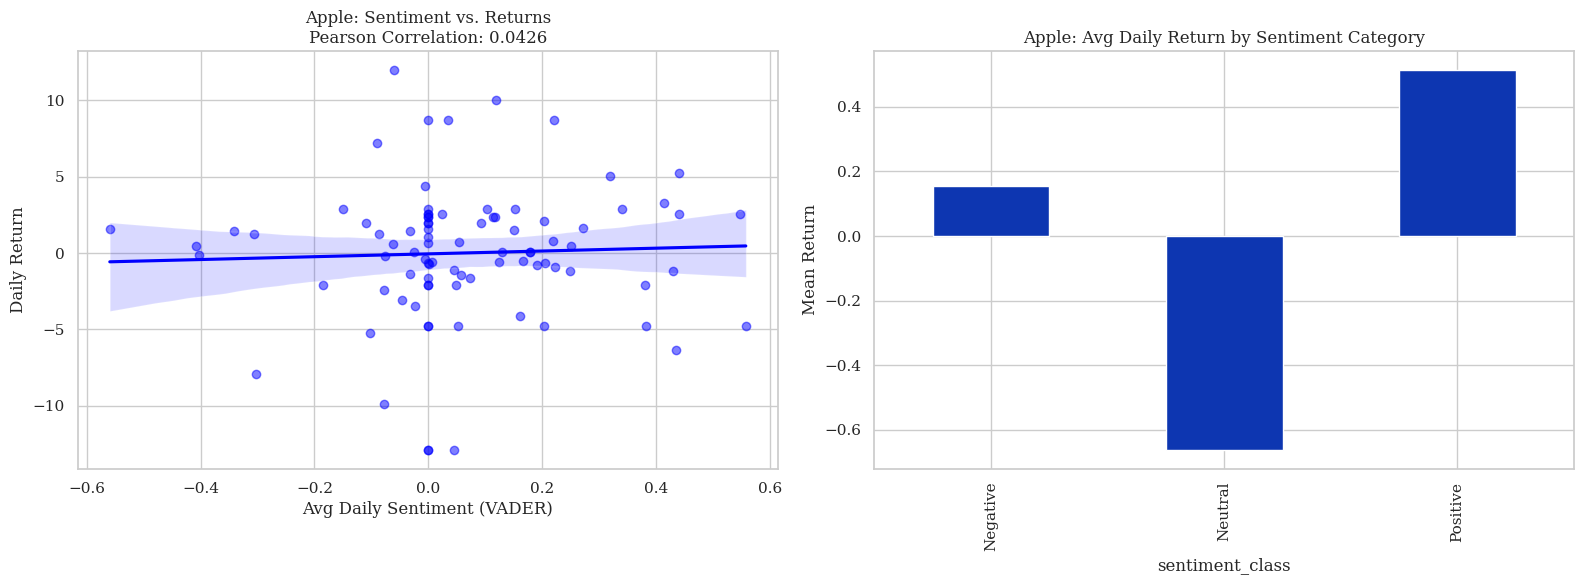

In [91]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Classification & Stats
final_apple['sentiment_class'] = final_apple['vader_compound'].apply(
    lambda x: 'Positive' if x >= 0.05 else ('Negative' if x <= -0.05 else 'Neutral')
)
apple_corr = final_apple['vader_compound'].corr(final_apple['Daily_Return'])

# 2. Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Scatter Plot with Correlation Annotation
sns.regplot(x='vader_compound', y='Daily_Return', data=final_apple, ax=ax1, color='blue', scatter_kws={'alpha':0.5})
ax1.set_title(f'Apple: Sentiment vs. Returns\nPearson Correlation: {apple_corr:.4f}')
ax1.set_xlabel('Avg Daily Sentiment (VADER)')
ax1.set_ylabel('Daily Return')

# Bar Chart of Avg Return per Category
apple_avg_returns = final_apple.groupby('sentiment_class')['Daily_Return'].mean().reindex(['Negative', 'Neutral', 'Positive'])
apple_avg_returns.plot(kind='bar', ax=ax2, color=["#0d36b1"])
ax2.set_title('Apple: Avg Daily Return by Sentiment Category')
ax2.set_ylabel('Mean Return')

plt.tight_layout()
plt.show()

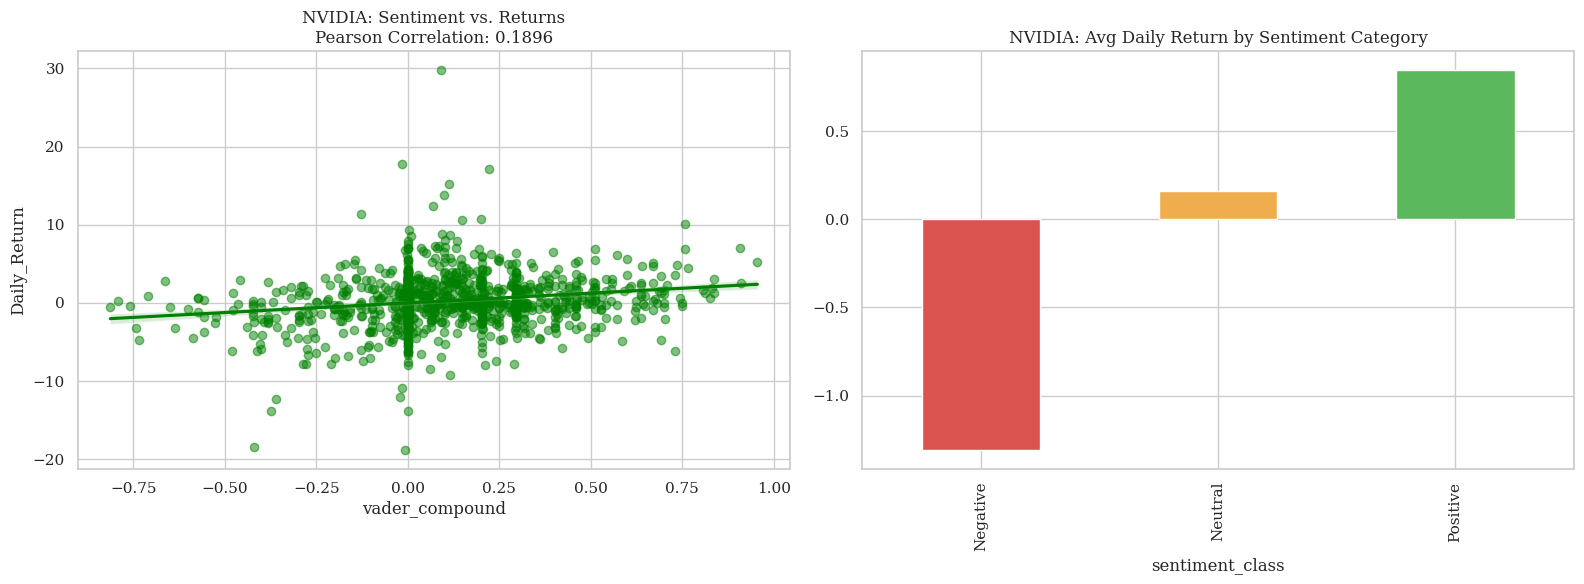

In [87]:
final_nvda['sentiment_class'] = final_nvda['vader_compound'].apply(
    lambda x: 'Positive' if x >= 0.05 else ('Negative' if x <= -0.05 else 'Neutral')
)
nvda_corr = final_nvda['vader_compound'].corr(final_nvda['Daily_Return'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.regplot(x='vader_compound', y='Daily_Return', data=final_nvda, ax=ax1, color='green', scatter_kws={'alpha':0.5})
ax1.set_title(f'NVIDIA: Sentiment vs. Returns\nPearson Correlation: {nvda_corr:.4f}')

nvda_avg_returns = final_nvda.groupby('sentiment_class')['Daily_Return'].mean().reindex(['Negative', 'Neutral', 'Positive'])
nvda_avg_returns.plot(kind='bar', ax=ax2, color=['#d9534f', '#f0ad4e', '#5cb85c'])
ax2.set_title('NVIDIA: Avg Daily Return by Sentiment Category')

plt.tight_layout()
plt.show()

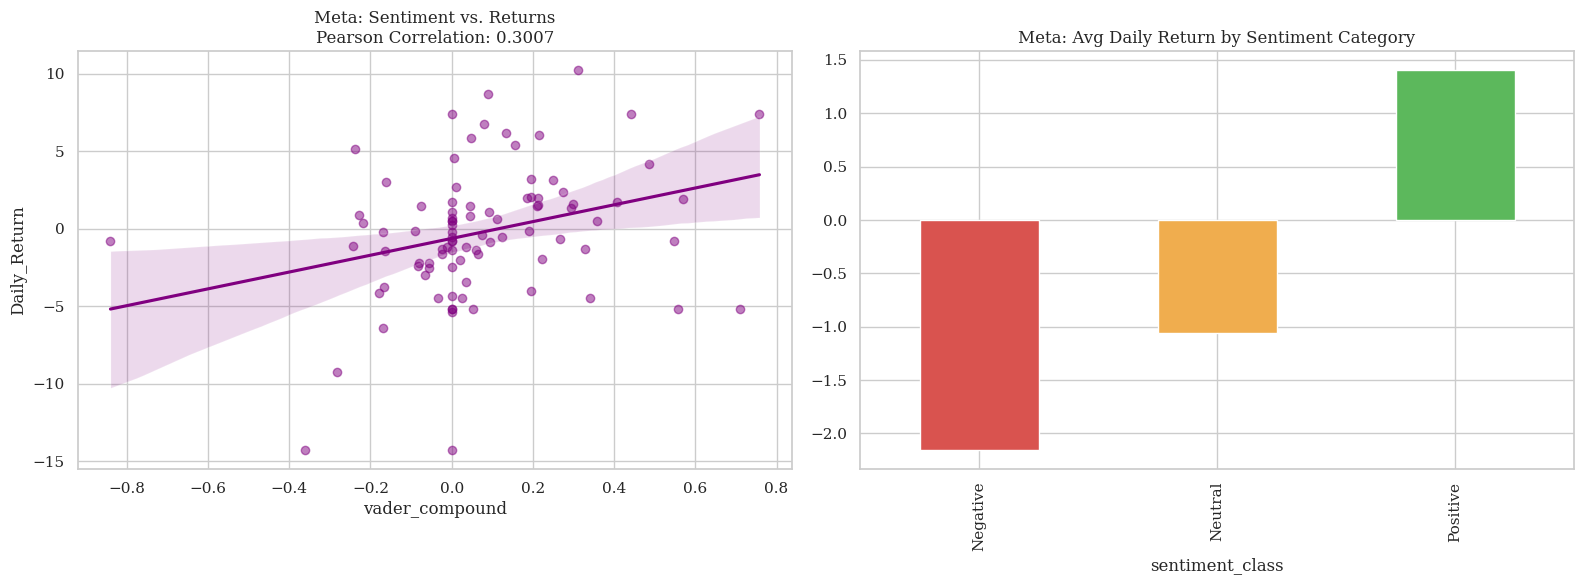

In [88]:
final_meta['sentiment_class'] = final_meta['vader_compound'].apply(
    lambda x: 'Positive' if x >= 0.05 else ('Negative' if x <= -0.05 else 'Neutral')
)
meta_corr = final_meta['vader_compound'].corr(final_meta['Daily_Return'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.regplot(x='vader_compound', y='Daily_Return', data=final_meta, ax=ax1, color='purple', scatter_kws={'alpha':0.5})
ax1.set_title(f'Meta: Sentiment vs. Returns\nPearson Correlation: {meta_corr:.4f}')

meta_avg_returns = final_meta.groupby('sentiment_class')['Daily_Return'].mean().reindex(['Negative', 'Neutral', 'Positive'])
meta_avg_returns.plot(kind='bar', ax=ax2, color=['#d9534f', '#f0ad4e', '#5cb85c'])
ax2.set_title('Meta: Avg Daily Return by Sentiment Category')

plt.tight_layout()
plt.show()

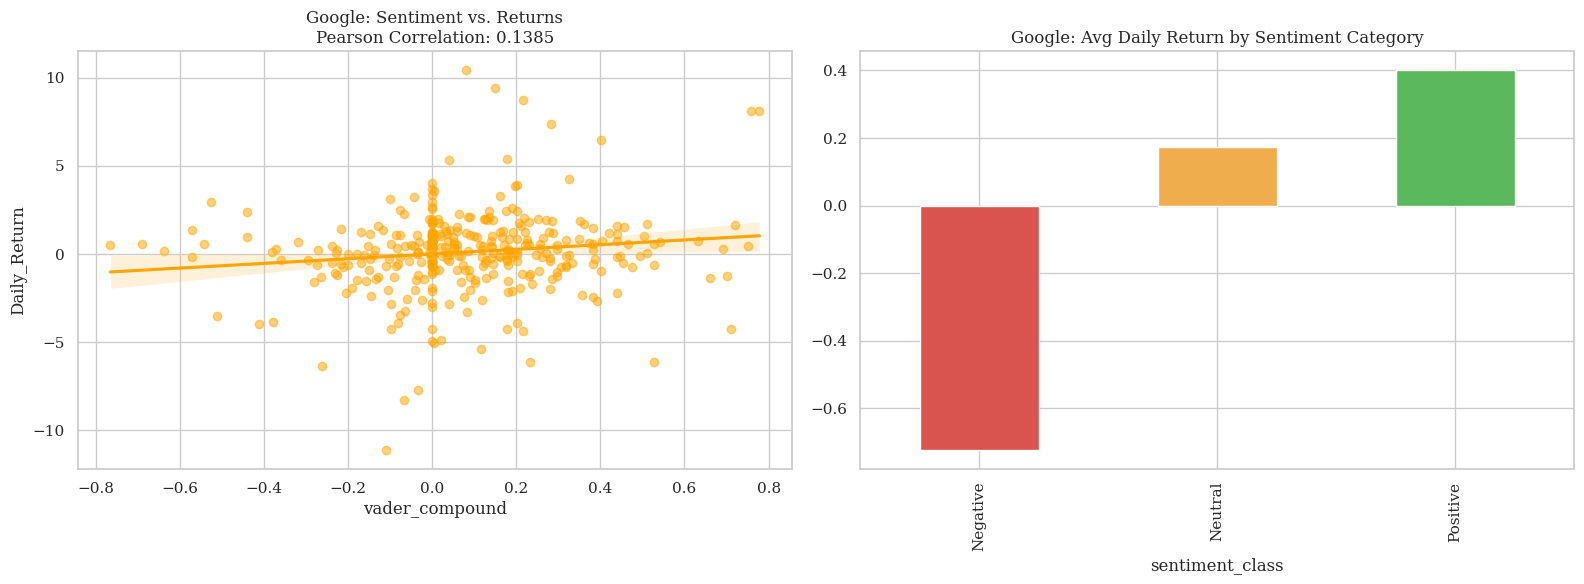

In [89]:
final_googl['sentiment_class'] = final_googl['vader_compound'].apply(
    lambda x: 'Positive' if x >= 0.05 else ('Negative' if x <= -0.05 else 'Neutral')
)
googl_corr = final_googl['vader_compound'].corr(final_googl['Daily_Return'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.regplot(x='vader_compound', y='Daily_Return', data=final_googl, ax=ax1, color='orange', scatter_kws={'alpha':0.5})
ax1.set_title(f'Google: Sentiment vs. Returns\nPearson Correlation: {googl_corr:.4f}')

googl_avg_returns = final_googl.groupby('sentiment_class')['Daily_Return'].mean().reindex(['Negative', 'Neutral', 'Positive'])
googl_avg_returns.plot(kind='bar', ax=ax2, color=['#d9534f', '#f0ad4e', '#5cb85c'])
ax2.set_title('Google: Avg Daily Return by Sentiment Category')

plt.tight_layout()
plt.show()

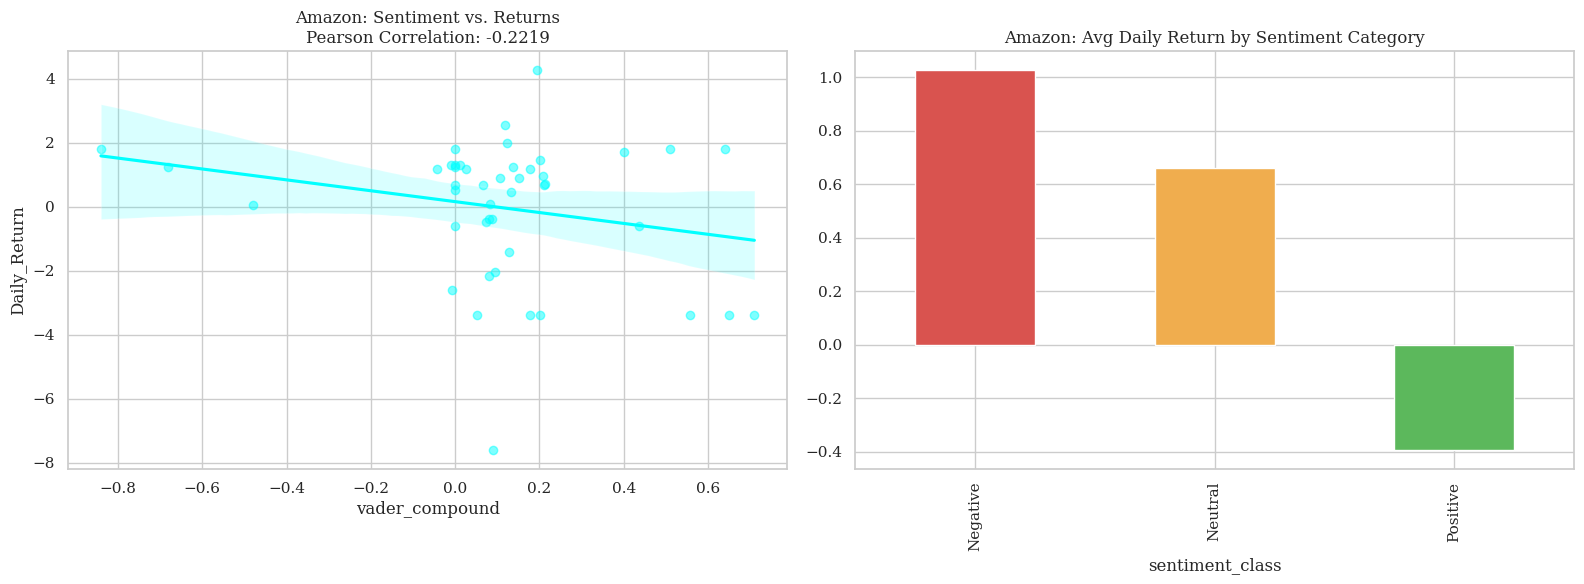

In [90]:
final_amzn['sentiment_class'] = final_amzn['vader_compound'].apply(
    lambda x: 'Positive' if x >= 0.05 else ('Negative' if x <= -0.05 else 'Neutral')
)
amzn_corr = final_amzn['vader_compound'].corr(final_amzn['Daily_Return'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.regplot(x='vader_compound', y='Daily_Return', data=final_amzn, ax=ax1, color='cyan', scatter_kws={'alpha':0.5})
ax1.set_title(f'Amazon: Sentiment vs. Returns\nPearson Correlation: {amzn_corr:.4f}')

amzn_avg_returns = final_amzn.groupby('sentiment_class')['Daily_Return'].mean().reindex(['Negative', 'Neutral', 'Positive'])
amzn_avg_returns.plot(kind='bar', ax=ax2, color=['#d9534f', '#f0ad4e', '#5cb85c'])
ax2.set_title('Amazon: Avg Daily Return by Sentiment Category')

plt.tight_layout()
plt.show()